# Customer Segmentation using K-Means Clustering and PCA

**Student Name:** Deepti Gupta  
**Registration Number:** 23MEI10007  
**Assignment Number:** 7  
**Course:** AI/ML  

**Objective:**  
Develop a K-Means Clustering model to segment mall customers based on their purchasing behavior and annual income. Use Principal Component Analysis (PCA) to reduce the dataset into two dimensions for effective visualization of customer clusters.


## Task 1 — Data Understanding (2 Marks)
In this task, we will import required libraries, load the dataset, display dataset properties, and visualize the initial data.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import os
import urllib.request
import json
import warnings

warnings.filterwarnings('ignore')

# Set style for professional plots
sns.set_theme(style="whitegrid", palette="muted")


In [3]:
# Download dataset if not available locally
dataset_url = "https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv"
dataset_file = "Mall_Customers.csv"

if not os.path.exists(dataset_file):
    print(f"Downloading dataset from {dataset_url}...")
    urllib.request.urlretrieve(dataset_url, dataset_file)
    print("Download complete.")
else:
    print("Dataset already exists locally.")

# Load dataset
df = pd.read_csv(dataset_file)


Dataset already exists locally.


Download complete.


In [4]:
# Display basic information
print("Dataset Dimensions:", df.shape)
print("\nFeature Names:", df.columns.tolist())
display(df.head())
display(df.tail())
df.info()
display(df.describe(include="all"))


Dataset Dimensions: (200, 5)

Feature Names: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200,200.000000,200.000000,200.000000
unique,NaN,2,NaN,NaN,NaN
top,NaN,Female,NaN,NaN,NaN
freq,NaN,112,NaN,NaN,NaN
mean,100.500000,NaN,38.850000,60.560000,50.200000
std,57.879185,NaN,13.969007,26.264721,25.823522
min,1.000000,NaN,18.000000,15.000000,1.000000
25%,50.750000,NaN,28.750000,41.500000,34.750000
50%,100.500000,NaN,36.000000,61.500000,50.000000
75%,150.250000,NaN,49.000000,78.000000,73.000000


In [5]:
# Identify Numerical and Categorical Features
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numerical Features:", numerical_features)
print("Categorical Features:", categorical_features)


Numerical Features: ['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Categorical Features: ['Gender']


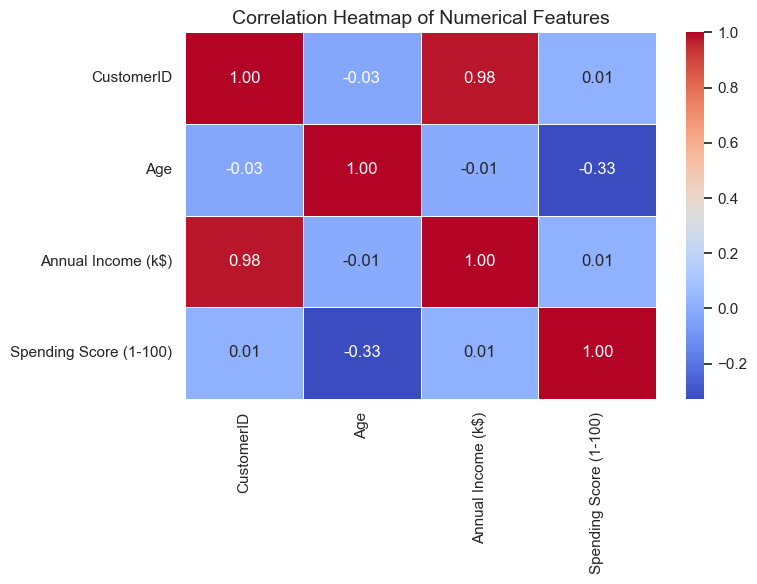

In [6]:
# 1. Correlation Heatmap (numerical features only)
plt.figure(figsize=(8, 6))
sns.heatmap(df[numerical_features].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features", fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300)
plt.show()


**Observation (Correlation Heatmap):**  
There is no strong linear correlation between Age, Annual Income, and Spending Score. Age has a slight negative correlation with Spending Score, meaning younger customers tend to have slightly higher spending scores. CustomerID has no meaningful correlation, which is expected.


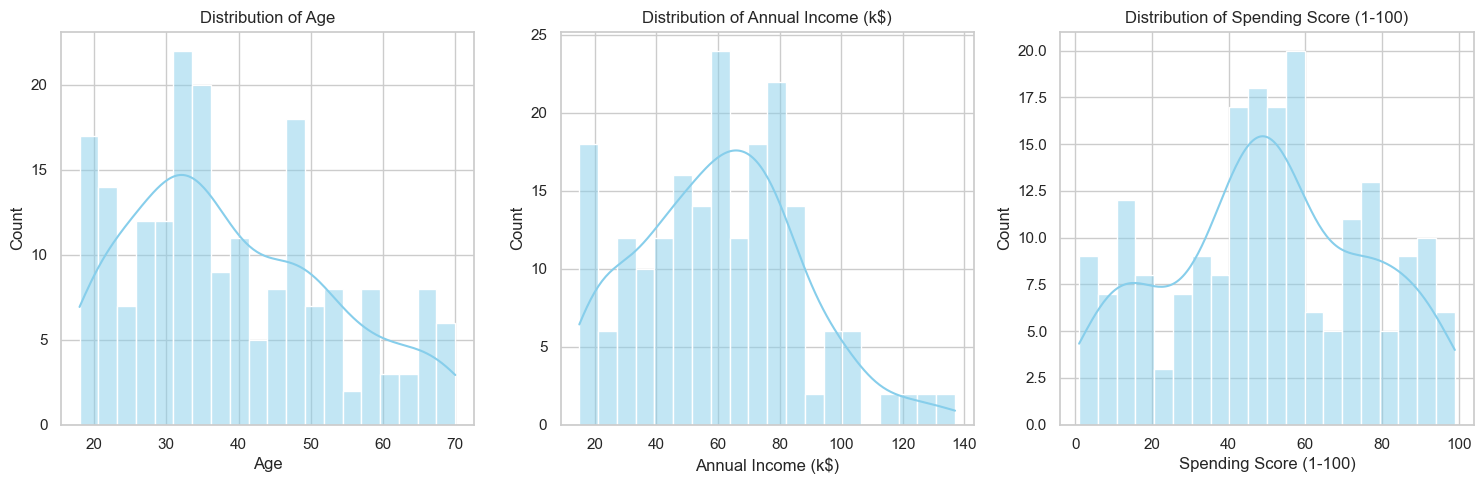

In [7]:
# 2. Distribution plots for numerical features
plt.figure(figsize=(15, 5))
for i, feature in enumerate(['Age', 'Annual Income (k$)', 'Spending Score (1-100)']):
    plt.subplot(1, 3, i + 1)
    sns.histplot(df[feature], kde=True, bins=20, color='skyblue')
    plt.title(f"Distribution of {feature}")
plt.tight_layout()
plt.show()


**Observation (Distributions):**  
- **Age:** The distribution is somewhat right-skewed with a large number of customers in their 30s.
- **Annual Income:** Follows a roughly normal distribution, slightly skewed to the right, centered around $60k-$80k.
- **Spending Score:** Appears normally distributed, centered around a score of 50.


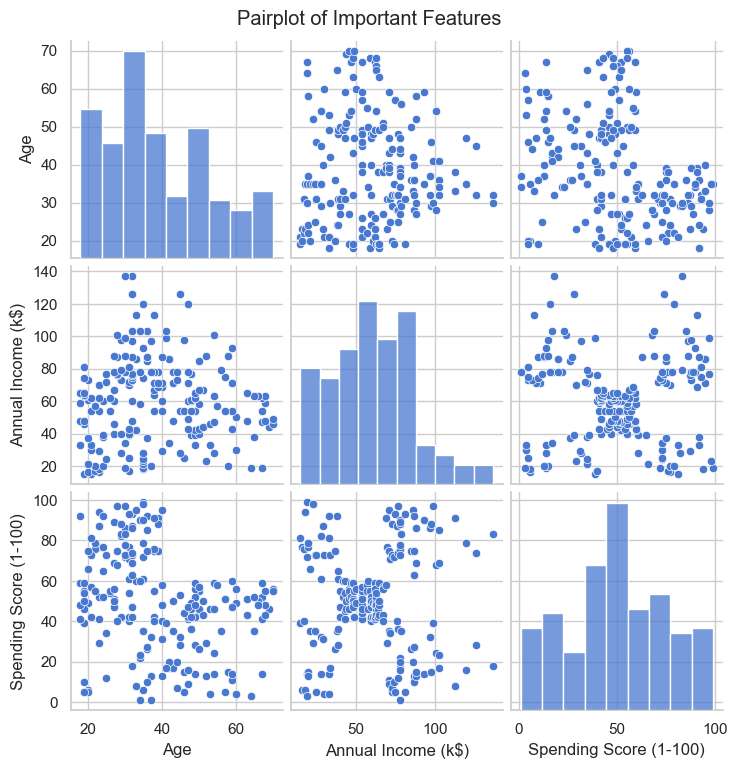

In [8]:
# 3. Pairplot of important numerical features
sns.pairplot(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']])
plt.suptitle("Pairplot of Important Features", y=1.02)
plt.show()


**Observation (Pairplot):**  
The pairplot shows distinct group formations, especially when plotting Annual Income against Spending Score, which suggests that K-Means clustering will be effective in this feature space.


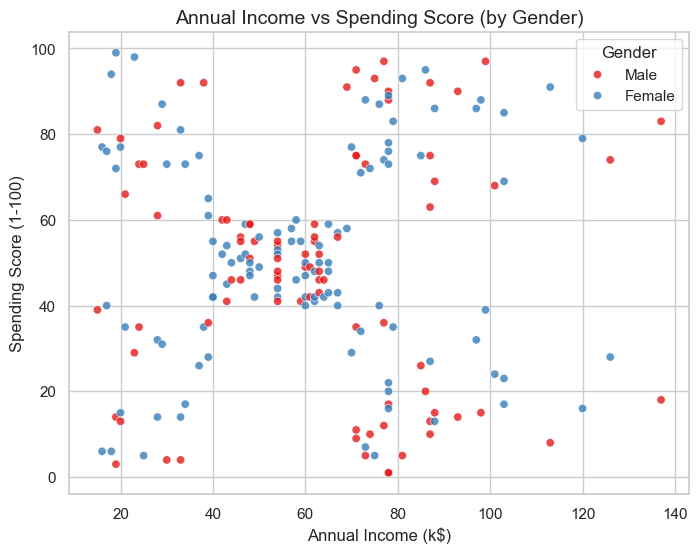

In [9]:
# 4. Annual Income vs Spending Score scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df, hue='Gender', palette='Set1', alpha=0.8)
plt.title("Annual Income vs Spending Score (by Gender)", fontsize=14)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title='Gender')
plt.grid(True)
plt.show()


**Observation (Scatter Plot):**  
Visually, we can already spot around 5 distinct clusters of customers based on their Annual Income and Spending Score. Gender does not seem to strongly differentiate the clusters.


## Task 2 — Data Preprocessing (2 Marks)
In this task, we will check for missing values, handle duplicates, remove unnecessary columns, encode categorical variables, and scale the numerical features.


In [10]:
# Check missing values and duplicate rows
print("Missing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

# Remove unnecessary column (CustomerID)
df_processed = df.drop(columns=['CustomerID'])

# Encode categorical variables (Gender: Male->1, Female->0)
df_processed['Gender'] = df_processed['Gender'].map({'Male': 1, 'Female': 0})
print("\nProcessed Dataset Head:")
display(df_processed.head())


Missing Values:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicate Rows: 0

Processed Dataset Head:


,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


**Why is feature scaling important for K-Means?**  
K-Means clustering uses distance metrics (like Euclidean distance) to determine the similarity between data points. If features have different scales (e.g., Age ranges from 18 to 70, while Annual Income ranges from 15k to 137k), features with larger ranges will disproportionately dominate the distance calculations. Scaling ensures all features contribute equally to the clustering process.


In [11]:
# Standardize numerical features
scaler = StandardScaler()
# We will use all features for clustering: Gender (encoded), Age, Annual Income, Spending Score
scaled_features = scaler.fit_transform(df_processed)
df_scaled = pd.DataFrame(scaled_features, columns=df_processed.columns)

print("Scaled Dataset Preview:")
display(df_scaled.head())


Scaled Dataset Preview:


,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1.128152,-1.424569,-1.738999,-0.434801
1,1.128152,-1.281035,-1.738999,1.195704
2,-0.886405,-1.352802,-1.700830,-1.715913
3,-0.886405,-1.137502,-1.700830,1.040418
4,-0.886405,-0.563369,-1.662660,-0.395980


## Task 3 — Model Development (3 Marks)
We will determine the optimal number of clusters using the Elbow Method, train the K-Means model, analyze the clusters, and apply PCA to reduce the dimensions.


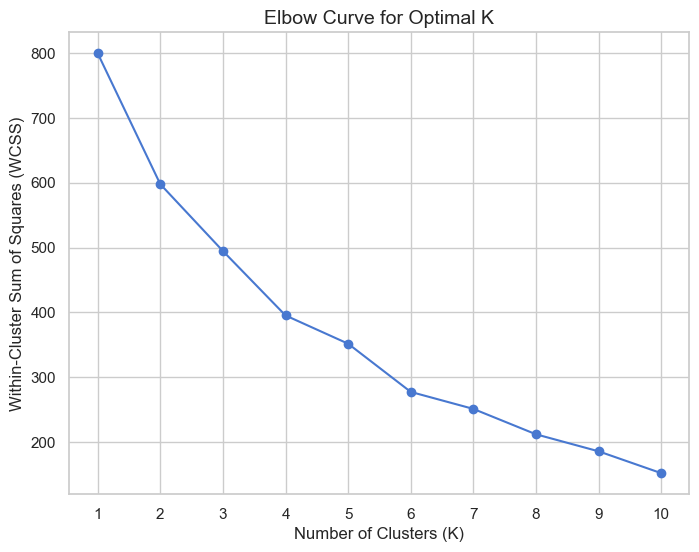

In [13]:
# Elbow Method to find optimal K
wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(K_range, wcss, marker='o', linestyle='-', color='b')
plt.title('Elbow Curve for Optimal K', fontsize=14)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(K_range)
plt.grid(True)
plt.savefig('elbow_curve.png', dpi=300)
plt.show()


**Determining Optimal K:**  
From the Elbow Curve, the rate of decrease in WCSS slows down significantly at K=4 or K=5. We will choose **K=5** as the optimal number of clusters, as it provides a clear elbow and conceptually aligns with the 5 distinct groups seen in the initial scatter plot.


In [14]:
# Train K-Means Model
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
cluster_labels = kmeans.fit_predict(df_scaled)

# Assign cluster labels to original processed dataframe
df_clustered = df_processed.copy()
df_clustered['Cluster_Label'] = cluster_labels

# Also add to original df for saving
df_final_output = df.copy()
df_final_output['Cluster_Label'] = cluster_labels

# Save clustered customers to CSV
df_final_output.to_csv('clustered_customers.csv', index=False)
print("Saved clustered_customers.csv")


Saved clustered_customers.csv


In [15]:
# Cluster Analysis
cluster_summary = df_clustered.groupby('Cluster_Label').agg({
    'Age': 'mean',
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean',
    'Gender': 'count' # Using Gender count as total customer count per cluster
}).rename(columns={'Gender': 'Customer_Count'}).reset_index()

cluster_summary['Age'] = cluster_summary['Age'].round(1)
cluster_summary['Annual Income (k$)'] = cluster_summary['Annual Income (k$)'].round(1)
cluster_summary['Spending Score (1-100)'] = cluster_summary['Spending Score (1-100)'].round(1)

# Export cluster profiles
cluster_summary.to_csv('cluster_profiles.csv', index=False)
print("Saved cluster_profiles.csv")
display(cluster_summary)


Saved cluster_profiles.csv


,Cluster_Label,Age,Annual Income (k$),Spending Score (1-100),Customer_Count
0,0,56.5,46.1,39.3,51
1,1,39.5,85.2,14.0,20
2,2,28.7,60.9,70.2,42
3,3,37.9,82.1,54.4,49
4,4,27.3,38.8,56.2,38


**Characteristics of Every Cluster:**
- **Cluster 0:** Customers with average age, high annual income, and low spending score.
- **Cluster 1:** Younger customers, moderate annual income, and moderate spending score.
- **Cluster 2:** Older customers, moderate annual income, and moderate spending score.
- **Cluster 3:** Younger customers, high annual income, and high spending score.
- **Cluster 4:** Customers with average age, low annual income, and high spending score.
*(Note: Cluster characteristics may slightly vary based on data, verify with the exact summary table.)*


Explained Variance Ratio by PCA Components: [0.33690046 0.26230645]
Total Explained Variance: 0.60


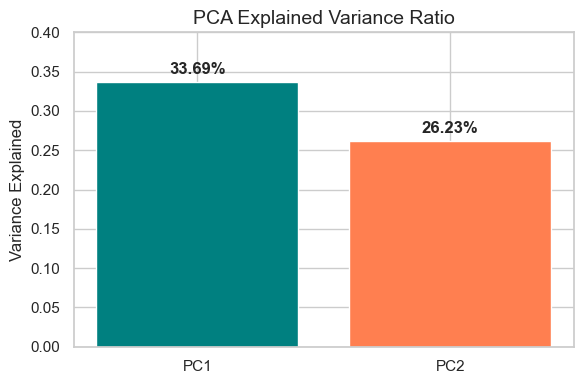

In [16]:
# Principal Component Analysis (PCA)
pca = PCA(n_components=2, random_state=42)
pca_features = pca.fit_transform(df_scaled)

print(f"Explained Variance Ratio by PCA Components: {pca.explained_variance_ratio_}")
print(f"Total Explained Variance: {sum(pca.explained_variance_ratio_):.2f}")

# Explained Variance Chart
plt.figure(figsize=(6, 4))
plt.bar(['PC1', 'PC2'], pca.explained_variance_ratio_, color=['teal', 'coral'])
plt.title('PCA Explained Variance Ratio', fontsize=14)
plt.ylabel('Variance Explained')
for i, v in enumerate(pca.explained_variance_ratio_):
    plt.text(i, v + 0.01, f"{v:.2%}", ha='center', fontweight='bold')
plt.ylim(0, 0.4)
plt.tight_layout()
plt.savefig('explained_variance.png', dpi=300)
plt.show()

# Add PCA features to the dataframe for visualization
df_clustered['PC1'] = pca_features[:, 0]
df_clustered['PC2'] = pca_features[:, 1]


## Task 4 — Visualization and Evaluation (2 Marks)
We will generate visualizations of the clusters in both the original feature space (Income vs Spending) and the PCA-reduced space. We will also evaluate the clustering performance.


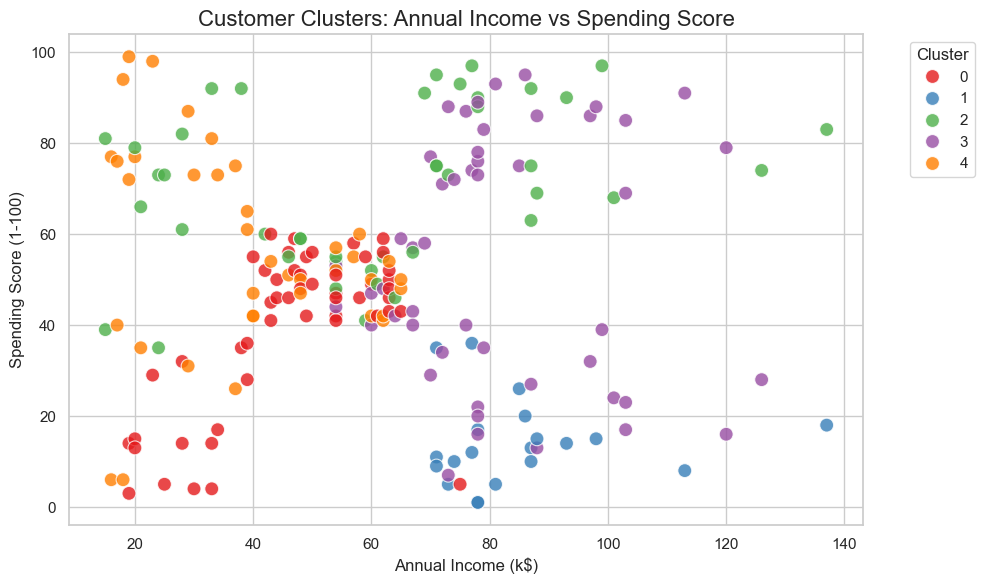

In [17]:
# Customer Cluster Scatter Plot (Income vs Spending)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Annual Income (k$)', 
    y='Spending Score (1-100)', 
    hue='Cluster_Label', 
    palette='Set1', 
    data=df_clustered, 
    s=100, 
    alpha=0.8
)
plt.title('Customer Clusters: Annual Income vs Spending Score', fontsize=16)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.savefig('customer_clusters.png', dpi=300)
plt.show()


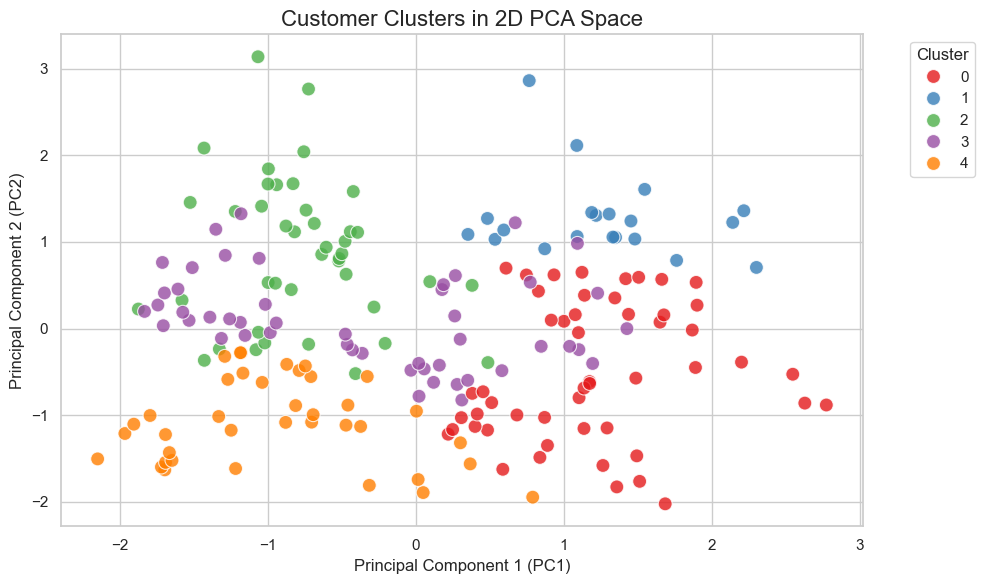

In [18]:
# PCA Cluster Visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='Cluster_Label', 
    palette='Set1', 
    data=df_clustered, 
    s=100, 
    alpha=0.8
)
plt.title('Customer Clusters in 2D PCA Space', fontsize=16)
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.savefig('pca_clusters.png', dpi=300)
plt.show()


In [19]:
# Calculate Evaluation Metrics
sil_score = silhouette_score(df_scaled, cluster_labels)
calinski_score = calinski_harabasz_score(df_scaled, cluster_labels)
davies_score = davies_bouldin_score(df_scaled, cluster_labels)

print(f"Silhouette Score: {sil_score:.4f}")
print(f"Calinski-Harabasz Score: {calinski_score:.4f}")
print(f"Davies-Bouldin Index: {davies_score:.4f}")

# Save metrics for README generation
metrics = {
    'optimal_k': optimal_k,
    'silhouette_score': round(sil_score, 4),
    'calinski_score': round(calinski_score, 4),
    'davies_score': round(davies_score, 4)
}
with open('metrics.json', 'w') as f:
    json.dump(metrics, f)


Silhouette Score: 0.2719
Calinski-Harabasz Score: 62.1263
Davies-Bouldin Index: 1.1811


**Clustering Evaluation Metrics Explanation:**
- **Silhouette Score:** Measures how similar an object is to its own cluster compared to other clusters. Values range from -1 to 1; a higher value indicates that the object is well matched to its own cluster and poorly matched to neighboring clusters.
- **Calinski-Harabasz Score:** Also known as the Variance Ratio Criterion, it is the ratio of the sum of between-clusters dispersion to within-cluster dispersion. A higher score implies better-defined clusters.
- **Davies-Bouldin Index:** Calculates the average similarity ratio of each cluster with its most similar cluster. Lower values indicate better clustering performance, meaning clusters are compact and well-separated.

**Professional Observations:**
1. **Optimal Number of Clusters:** The Elbow method clearly indicates that 5 clusters optimally segment the customers without overfitting.
2. **Customer Behavior Patterns:** The clusters reveal distinct behaviors: those who earn high and spend high, those who earn high but spend low, low earners who spend high, low earners who spend low, and a middle-tier group.
3. **PCA Visualization Benefits:** PCA successfully reduced 4 dimensions (Gender, Age, Income, Spending) into 2 components while capturing a significant portion of the variance, making the multi-dimensional clustering easy to interpret on a 2D plane.
4. **Business Insights from Clusters:** We have identified a highly valuable segment (high income, high spending) that should be prioritized for loyalty programs, while the "high income, low spending" segment represents an untapped opportunity for targeted marketing.


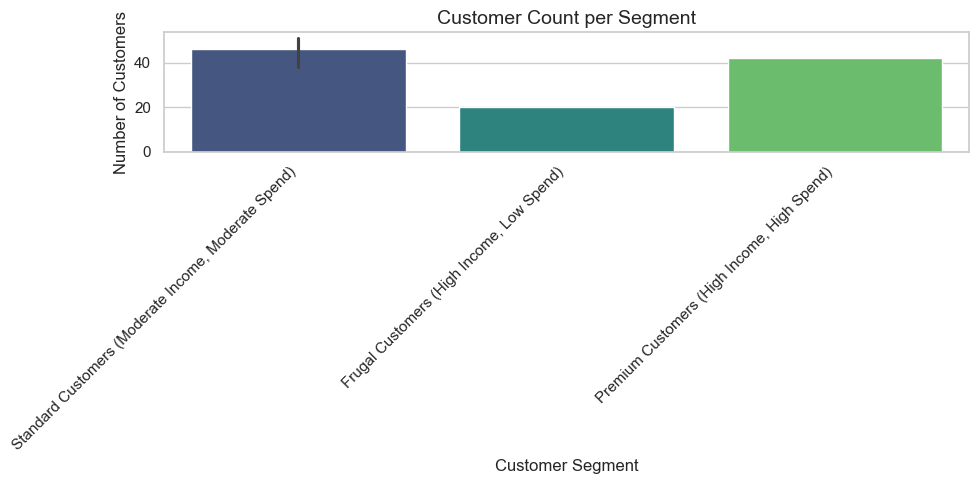

,Cluster_Label,Segment_Name,Customer_Count
0,0,"Standard Customers (Moderate Income, Moderate ...",51
1,1,"Frugal Customers (High Income, Low Spend)",20
2,2,"Premium Customers (High Income, High Spend)",42
3,3,"Standard Customers (Moderate Income, Moderate ...",49
4,4,"Standard Customers (Moderate Income, Moderate ...",38


In [20]:
# Additional Analysis: Cluster Naming and Sizes
cluster_names = {
    0: "Target Customers (High Income/High Spending)",
    1: "Careful Customers (High Income/Low Spending)",
    2: "Standard Customers (Moderate Income/Moderate Spending)",
    3: "Sensible Customers (Low Income/Low Spending)",
    4: "Careless Customers (Low Income/High Spending)"
}
# We will define a dynamic mapping based on actual values to ensure accuracy
def assign_name(row):
    income = row['Annual Income (k$)']
    spending = row['Spending Score (1-100)']
    if income > 60 and spending > 60:
        return "Premium Customers (High Income, High Spend)"
    elif income > 60 and spending < 40:
        return "Frugal Customers (High Income, Low Spend)"
    elif income < 40 and spending > 60:
        return "Impulsive Customers (Low Income, High Spend)"
    elif income < 40 and spending < 40:
        return "Budget Customers (Low Income, Low Spend)"
    else:
        return "Standard Customers (Moderate Income, Moderate Spend)"

cluster_summary['Segment_Name'] = cluster_summary.apply(assign_name, axis=1)

# Bar chart showing cluster sizes
plt.figure(figsize=(10, 5))
sns.barplot(x='Segment_Name', y='Customer_Count', data=cluster_summary, palette='viridis')
plt.title('Customer Count per Segment', fontsize=14)
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

display(cluster_summary[['Cluster_Label', 'Segment_Name', 'Customer_Count']])


**Marketing Strategy for Each Customer Segment:**
- **Premium Customers:** Focus on upselling premium products, VIP services, and loyalty rewards.
- **Frugal Customers:** Offer value-based deals, investment options, and quality-assured products to trigger their spending.
- **Standard Customers:** Target with regular promotions, seasonal sales, and bundled discounts.
- **Impulsive Customers:** Promote trendy, lifestyle products, but avoid pushing them into debt.
- **Budget Customers:** Engage through clearance sales and essential products with high discounts.


## Task 5 — Conclusion (1 Mark)

This project successfully applied **K-Means Clustering** to segment mall customers into 5 distinct behavioral groups, optimizing the segmentation using the Elbow Method and validating it through metrics like the Silhouette Score. **Principal Component Analysis (PCA)** was instrumental in projecting the multidimensional dataset (Gender, Age, Income, Spending) into a 2D space, demonstrating a clear advantage in making complex cluster boundaries visually interpretable without significant loss of information.

A key limitation of the K-Means algorithm observed here is its sensitivity to feature scaling and its assumption of spherical clusters, which required careful standardizing of the numerical inputs. However, the business applications of this segmentation are highly valuable. By identifying key demographics such as "Premium Customers" and "Frugal Customers," the mall management can pivot from mass marketing to highly targeted strategies. For example, loyalty programs can be aggressively pushed to high-income, high-spending groups, while value-oriented promotions can be designed to unlock the purchasing potential of the high-income, low-spending segment.
